In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

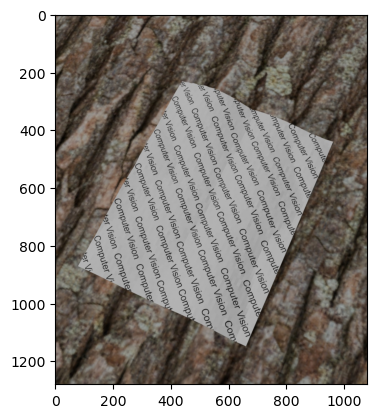

In [70]:
image = cv2.imread("synthetic_data/input (4).jpg")
# show color image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

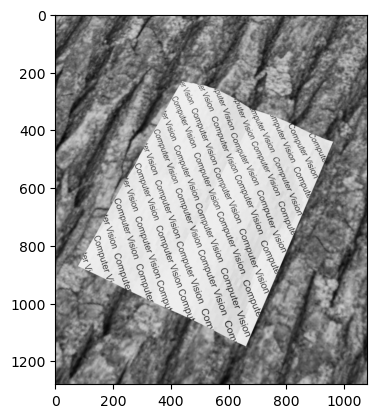

In [71]:
imGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(imGray, cmap='gray')

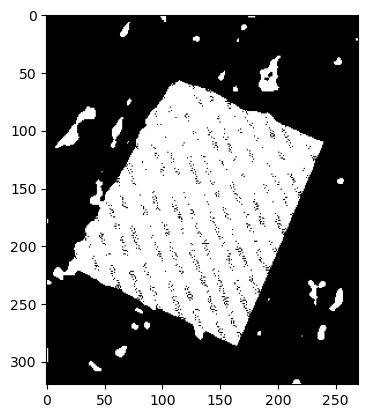

In [72]:
img_scale = 0.25
small = cv2.resize(imGray, None, fx=img_scale, fy=img_scale)
small_color = cv2.resize(image, None, fx=img_scale, fy=img_scale)
blurred_small = cv2.bilateralFilter(small, 9, 75, 75)
_, otsuThresh = cv2.threshold(blurred_small, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(otsuThresh, cmap='gray')

In [73]:
kernel = np.ones((5,5), np.uint8)
cleaned = cv2.morphologyEx(otsuThresh, cv2.MORPH_OPEN, kernel)
cnts, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
maxContour = max(cnts, key=cv2.contourArea)
hull = cv2.convexHull(maxContour)

Found 4 points with scale 0.03


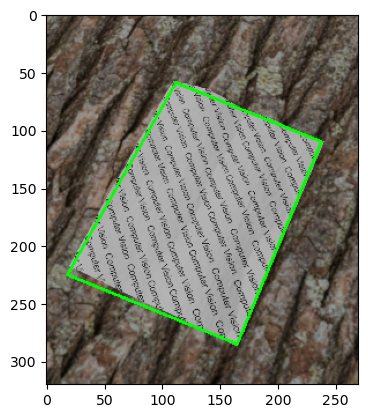

In [74]:
for scale in [0.02, 0.03, 0.04, 0.05, 0.06, 0.1]:
    epsilon = scale * cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, epsilon, True)
    if len(approx) == 4:
        print(f"Found 4 points with scale {scale}")
        break

output = small_color.copy()
cv2.drawContours(output, [approx], -1, (0, 255, 0), 2)  # green polygon
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

In [75]:
approx_full = (approx / img_scale).astype(np.int32)

In [76]:
# TODO: order the approx points consistently (clockwise starting from top-left)
coordinate_sums = approx_full.sum(axis=2)
coordinate_diffs = np.diff(approx_full, axis=2)
top_left = approx_full[np.argmin(coordinate_sums)]
bottom_right = approx_full[np.argmax(coordinate_sums)]
top_right = approx_full[np.argmin(coordinate_diffs)]
bottom_left = approx_full[np.argmax(coordinate_diffs)]

ordered_approx = np.array([top_left, top_right, bottom_right, bottom_left])
ordered_approx = ordered_approx.reshape(4, 2)

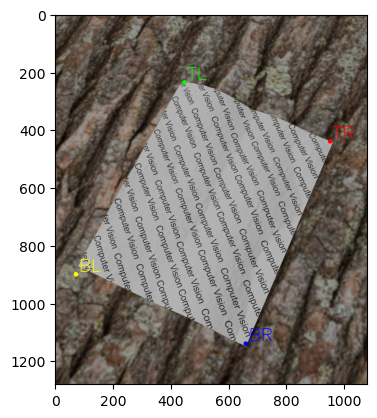

In [77]:
output = image.copy()
colors = [(0,255,0), (0,0,255), (255,0,0), (0,255,255)]  # TL, TR, BR, BL
labels = ['TL', 'TR', 'BR', 'BL']

for i, (x, y) in enumerate(ordered_approx):
    cv2.circle(output, (x, y), 8, colors[i], -1)           # draw colored circle
    cv2.putText(output, labels[i], (x+10, y-10),           # add label
                cv2.FONT_HERSHEY_SIMPLEX, 2.0, colors[i], 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))